# F1 chili pepper fruit-shape prediction from parental EFDs (PPδ trial) — reproduction

**Paper**: Fumiya Kondo, Yui Kumanomido, Mariasilvia D'Andrea, Valentino Palombo, Nahed Ahmed, Shino Futatsuyama, Kazuhiro Nemoto, Kenichi Matsushima: *Prediction of fruit shapes in F1 progenies of chili peppers (Capsicum annuum) based on parental image data using elliptic Fourier analysis*, **Computers and Electronics in Agriculture 236 (2025) 110422**, https://doi.org/10.1016/j.compag.2025.110422

**Author code**: https://github.com/kondo238/Chili-Pepper-F1-Fruit-Shape-Prediction @ commit `87d422e29d6c3b52cb08e953eb52bc106a748de1`

**Scope (partial demonstration)**: This notebook runs the author's self-contained **PPδ trial** (`Trial_for_F1_fruit_shape_prediction/TrialScript.R`): one F1 fruit-shape prediction from two parents' elliptic Fourier descriptors (EFDs, 20 harmonics, 2 view directions × 5 fruits per parent, exported from the SHAPE program as `.nef` files) plus the author's representative dominance/additive ratio CSV. It redraws the parental raw/averaged contours and the predicted F1 contours, exactly as the author script does.

**Out of scope**: the full 291-accession GP[20]/GP[132]/PPmid/PPδ analyses (Parts 1–3), dataset-level accuracies, and every quantitative claim of the article — the article full text was not verified, so nothing here validates published results; it only executes the authors' own trial pipeline on the authors' own example data.

**AI-assisted adaptation statement**: This notebook is an AI-generated launcher for the authors' R code; the authors did not provide a Colab implementation. The R script itself is downloaded **verbatim** from the pinned commit and executed with `Rscript`; the only AI additions are `png()` device open/close around the two plotting blocks and one `write.csv()` of the predicted EFD table (see the marked cell for the exact inserted lines). The executed example and listed checks were validated, but untested behavior is not guaranteed.

**AI による補足**: 本ノートブックは著者らの R コードをそのまま pinned commit から取得して実行する AI 生成ランチャーです。著者コードへの追加は画像デバイス(`png`)の開閉と予測 EFD の CSV 出力のみで、科学的処理は変更していません。記事本文は未検証のため、本ノートブックは論文の数値結果を検証するものではありません。

## Runtime selection (CPU only — Run all)

**Select Runtime → Run all on a standard CPU runtime.** The workload is base-R vector arithmetic on a few dozen EFD rows and 56 tiny contour plots — seconds of CPU. There is **no GPU path**: the author pipeline has no neural network, no CUDA code, and GPU would not change any scientific operation. Expected wall time: well under 5 minutes; total download ≈ 34 KB.

**日本語**: GPU は不要です。標準 CPU ランタイムで「ランタイム → すべてのセルを実行」してください。所要 5 分未満、ダウンロードは約 34 KB です。

In [ ]:
import os, platform, shutil, subprocess, sys

print("Python:", platform.python_version())
rscript = shutil.which("Rscript")
if rscript is None:
    # Standard Colab CPU images ship R; install only if absent (documented fallback).
    print("Rscript not found; installing r-base-core ...")
    subprocess.run(["apt-get", "update", "-qq"], check=True, timeout=600)
    subprocess.run(["apt-get", "install", "-y", "--no-install-recommends", "r-base-core"],
                   check=True, timeout=1800)
    rscript = "/usr/bin/Rscript"
RSCRIPT = rscript
print("Rscript:", RSCRIPT)
print(subprocess.run([RSCRIPT, "--version"], capture_output=True, text=True).stdout.splitlines()[0])

Python: 3.13.16
Rscript: /usr/bin/Rscript
Rscript (R) version 4.6.1 (2026-06-24)


## 1. Input acquisition — pinned author data (Colab-only download)

The five input files are the authors' own example data: `Parent1_a/b.nef`, `Parent2_a/b.nef` (SHAPE-program EFD exports; 2 view directions of 2 parents, 5 fruits each per direction) and `Representative_ratio_between_dominance_and_additive_effect.csv` (the fixed dominance:additive ratio used by PPδ, derived from the authors' 156 F1 accessions). They are downloaded **here, inside Colab**, from the pinned commit `87d422e2…`; per-file byte size and git blob SHA-1 (from the GitHub tree API) are verified, and any HTML error page is rejected. Sizes/hashes below are GitHub metadata pinned at authoring time.

**日本語**: 著者提供のサンプルデータ(`.nef` ×4 と代表比 CSV)を pinned commit から Colab 内でダウンロードし、サイズと git blob SHA-1 を検証します。

In [ ]:
import hashlib
from pathlib import Path
import urllib.request

COMMIT = "87d422e29d6c3b52cb08e953eb52bc106a748de1"
BASE = (f"https://raw.githubusercontent.com/kondo238/"
        f"Chili-Pepper-F1-Fruit-Shape-Prediction/{COMMIT}/")
TRIAL_DIR = "Trial_for_F1_fruit_shape_prediction"
EXPECTED = {  # repo path under TRIAL_DIR: (bytes, git blob sha1)  <- GitHub tree API metadata @ COMMIT
    "Dataset/Parent1_a.nef": (6257, "55c32c888b485c3159bf3fe6829f0c0ef483b02c"),
    "Dataset/Parent1_b.nef": (6257, "f1cabf2904db14bf05c5ca6dcebc7061caf2cd7a"),
    "Dataset/Parent2_a.nef": (6257, "de0b9a5eaed4e6fa6828c91fdeb35e5794966d09"),
    "Dataset/Parent2_b.nef": (6257, "7d1f1de4c83cb9c8820eb4b220700298f5b0a8a1"),
    "Dataset/Representative_ratio_between_dominance_and_additive_effect.csv":
        (3361, "afbfeeb70af245e74d020baf869877e0ac9dce81"),
    "TrialScript.R": (13343, "87df5142dc781ae859a5f55d3ba23a6c21ba315b"),
}
EXPECTED = {f"{TRIAL_DIR}/{rel}": v for rel, v in EXPECTED.items()}

def git_blob_sha(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

Path("/content/Dataset").mkdir(parents=True, exist_ok=True)
for rel, (size, blob) in EXPECTED.items():
    # local layout mirrors the author script: ./Dataset/* next to TrialScript.R
    name = Path(rel).name
    local = Path("/content/Dataset") / name if "/Dataset/" in rel else Path("/content") / name
    with urllib.request.urlopen(BASE + rel, timeout=120) as r:
        data = r.read()
    assert r.status == 200 and len(data) == size, (rel, r.status, len(data))
    assert not data.lstrip().startswith(b"<"), f"{rel}: looks like HTML, not data"
    assert git_blob_sha(data) == blob, f"{rel}: git blob hash mismatch"
    local.write_bytes(data)
    print(f"OK  {rel:71s} {len(data):6d} B  blob {blob[:12]}... -> {local}")

OK  Trial_for_F1_fruit_shape_prediction/Dataset/Parent1_a.nef                 6257 B  blob 55c32c888b48... -> /content/Dataset/Parent1_a.nef


OK  Trial_for_F1_fruit_shape_prediction/Dataset/Parent1_b.nef                 6257 B  blob f1cabf2904db... -> /content/Dataset/Parent1_b.nef
OK  Trial_for_F1_fruit_shape_prediction/Dataset/Parent2_a.nef                 6257 B  blob de0b9a5eaed4... -> /content/Dataset/Parent2_a.nef


OK  Trial_for_F1_fruit_shape_prediction/Dataset/Parent2_b.nef                 6257 B  blob 7d1f1de4c83c... -> /content/Dataset/Parent2_b.nef


OK  Trial_for_F1_fruit_shape_prediction/Dataset/Representative_ratio_between_dominance_and_additive_effect.csv   3361 B  blob afbfeeb70af2... -> /content/Dataset/Representative_ratio_between_dominance_and_additive_effect.csv
OK  Trial_for_F1_fruit_shape_prediction/TrialScript.R                        13343 B  blob 87df5142dc78... -> /content/TrialScript.R


## 2. Input preview (structure only — no scientific processing yet)

The `.nef` files are whitespace-separated text exports from the SHAPE program (EFDs, 20 harmonics). The parsing loop in `TrialScript.R` expects 5 columns per line and 5 blocks of 21 lines (1 block header + 20 harmonics) per file; exact row layout is confirmed here from the downloaded bytes rather than assumed. The ratio CSV holds the per-direction dominance/additive representative ratios.

**日本語**: `.nef` は SHAPE 出力の空白区切りテキスト(20 調波)。ここではダウンロード実データの構造(行数・列数・先頭行)を確認します。

In [ ]:
lines = Path("/content/Dataset/Parent1_a.nef").read_text().splitlines()
widths = {len(l.split()) for l in lines if l.strip()}
print(f"Parent1_a.nef: {len(lines)} lines, fields/line = {sorted(widths)}")
print("--- first 4 lines ---")
for l in lines[:4]:
    print(" ", l)
assert max(widths) == 5, "unexpected column count for SHAPE .nef export"
assert len(lines) >= 5 * 21, "too few lines for 5 fruit blocks of 20 harmonics"

for other in ["Parent1_b.nef", "Parent2_a.nef", "Parent2_b.nef"]:
    n = len(Path("/content/Dataset", other).read_text().splitlines())
    print(f"{other}: {n} lines")

rep = Path("/content/Dataset",
           "Representative_ratio_between_dominance_and_additive_effect.csv").read_text().splitlines()
print(f"\nRepresentative_ratio...csv: {len(rep)} lines; first 3:")
for l in rep[:3]:
    print(" ", l)

Parent1_a.nef: 107 lines, fields/line = [1, 2, 4, 5]
--- first 4 lines ---
  #CONST 1 1 1 0
  #HARMO 20
  P1_1
    1.0000000e+00 -6.1210621e-17  8.8772138e-17  7.5867657e-01
Parent1_b.nef: 107 lines
Parent2_a.nef: 107 lines
Parent2_b.nef: 107 lines

Representative_ratio...csv: 3 lines; first 3:
  "Direction","ID","a1","a2","a3","a4","a5","a6","a7","a8","a9","a10","a11","a12","a13","a14","a15","a16","a17","a18","a19","a20","b1","b2","b3","b4","b5","b6","b7","b8","b9","b10","b11","b12","b13","b14","b15","b16","b17","b18","b19","b20","c1","c2","c3","c4","c5","c6","c7","c8","c9","c10","c11","c12","c13","c14","c15","c16","c17","c18","c19","c20","d1","d2","d3","d4","d5","d6","d7","d8","d9","d10","d11","d12","d13","d14","d15","d16","d17","d18","d19","d20"
  "a","Representative",NA,0.0286859684454217,0.76484686177237,0.116973789829474,0.625578812753251,0.778227769319793,0.313414827893276,1.30974282871554,0.27084884071285,0.464868694539565,0.607156347791968,0.550377494640536,0.862641420632343,0

## 3. Prepare the author's script — verbatim code + minimal AI glue

`TrialScript.R` is executed **verbatim** (same pinned commit) except for four AI-inserted, non-scientific lines needed for headless execution:
1. `png(...)` before the parental-contour block (`par(mfrow=c(length(ID),12))`) — base-R plots need a file device under `Rscript`.
2. `dev.off()` after that block.
3. `png(...)` before the predicted-F1 block (`par(mfrow=c(2,16))`).
4. `write.csv(Pre_df, ...)` so the predicted F1 EFDs survive the script's workspace cleanup, plus a final `dev.off()`.

Each insertion is anchored to a line that must occur exactly once in the pinned script — if the anchor check fails, the cell aborts instead of silently running modified science. Plot pixel sizes are a display choice only. The inserted lines are echoed below.

**日本語**: 著者スクリプトを原文のまま使います。追加は headless 実行に必要な `png()` デバイス 2 組と予測 EFD の `write.csv()` のみで、アンカーが一意であることを確認してから挿入します。

In [ ]:
script = Path("/content/TrialScript.R").read_text()

def insert_once(text: str, anchor: str, glue: str) -> str:
    assert text.count(anchor) == 1, f"anchor not unique in pinned script: {anchor!r}"
    return text.replace(anchor, glue + "\n" + anchor)

script = insert_once(script, "par(mfrow = c(length(ID), 12)",
    'png("/content/fig1_parental_contours.png", width=2000, height=400, res=100)')
script = insert_once(script,
    "rm(x, ef, coord, lw, i, Direction, r, ef2coord, mt, ave_mt, ID, Replicate)",
    "dev.off()")
script = insert_once(script, "par(mfrow = c(2, 16)",
    'png("/content/fig2_predicted_F1_contours.png", width=2200, height=320, res=100)')
script = insert_once(script,
    "rm(d_est, pheno_P1, pheno_P2, Pre_df2, Pre_df3, a, Direction, i, ID, j, "
    "midpoint, p1, p1h, p2, p2h, pre_pheno, Replicate, x)",
    'write.csv(Pre_df, "/content/predicted_F1_EFD.csv", row.names = FALSE)')
script += "\ndev.off()\n"

Path("/content/run_trial.R").write_text(script)
print("Inserted lines (the ONLY AI additions to the author script):")
for line in script.splitlines():
    if ("png(" in line and line.strip().startswith('png')) or \
       line.strip() in {"dev.off()"} or "write.csv(Pre_df" in line:
        print("  +", line)

Inserted lines (the ONLY AI additions to the author script):
  + png("/content/fig1_parental_contours.png", width=2000, height=400, res=100)
  + dev.off()
  + write.csv(Pre_df, "/content/predicted_F1_EFD.csv", row.names = FALSE)
  + png("/content/fig2_predicted_F1_contours.png", width=2200, height=320, res=100)
  + dev.off()


## 4. Run the PPδ trial (`Rscript`)

Python here is only the launcher (the Colab CLI drives a Python kernel; the author code is R). The script loads the 4 `.nef` files, averages the 5 fruit replicates per direction, computes PPδ predictions — midpoint of parental EFDs + |Δ|/2 × representative dominance ratio, with the `a1=1, b1=0, c1=0` constants — and draws the contours. A non-zero exit code raises instead of being hidden.

**日本語**: Python は起動用のみで、解析は著者の R コードが `Rscript` で実行します。終了コードが非ゼロならエラーとして扱います。

In [ ]:
import subprocess

proc = subprocess.run([RSCRIPT, "run_trial.R"], cwd="/content",
                      capture_output=True, text=True, timeout=600)
print("stderr (tail):", proc.stderr[-1500:] if proc.stderr else "(empty)")
print("returncode:", proc.returncode)
proc.check_returncode()  # fail loudly if the author script failed

for name in ["fig1_parental_contours.png", "fig2_predicted_F1_contours.png",
             "predicted_F1_EFD.csv"]:
    p = Path("/content", name)
    print(f"{name}: {p.stat().st_size} bytes")

stderr (tail): (empty)
returncode: 0
fig1_parental_contours.png: 87208 bytes
fig2_predicted_F1_contours.png: 105837 bytes
predicted_F1_EFD.csv: 48342 bytes


## 5. Result — parental raw vs averaged EFD contours

The authors' Step-2 figure: rows = Parent1 / Parent2; within each row, Direction 1 (left 6) and Direction 2 (right 6); **red = averaged EFD**, **black = raw EFD of each of the 5 fruits**. This is the input-side view of the prediction (parental phenotypes from which PPδ starts), rendered from the downloaded `.nef` bytes.

**日本語**: 親2系統の生 EFD(黒、5 果実ずつ)と平均 EFD(赤)の輪郭。赤が PPδ の入力となる平均形質です。

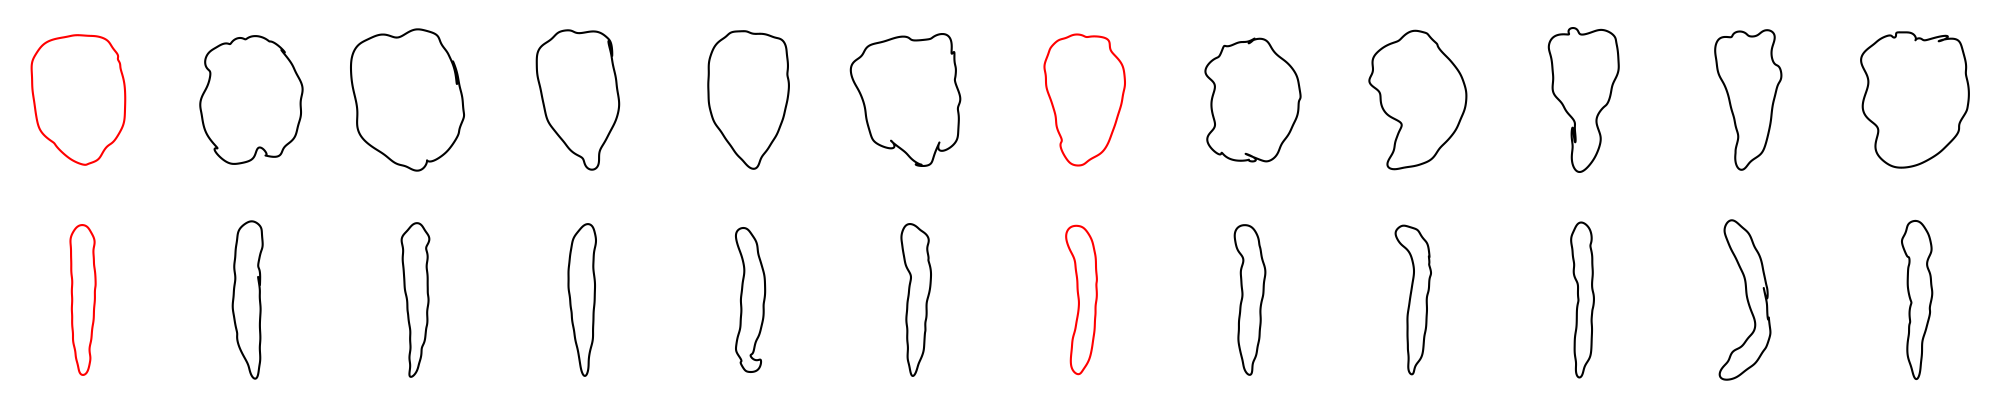

In [ ]:
from IPython.display import Image, display

display(Image(filename="/content/fig1_parental_contours.png"))

## 6. Result — predicted F1 contours (PPδ)

The authors' Step-3 figure: row 1 = Direction 1, row 2 = Direction 2; **red = PPδ prediction from the averaged parental EFDs** (`Parent1_X_Parent2`), **black = the 15 replicate-wise raw-EFD predictions** (`Parent1_Px_X_Parent2_Py`). This is the notebook's core output — the F1 fruit shapes predicted by the paper's PPδ method on the authors' example parents.

**日本語**: PPδ による F1 果実形態の予測輪郭。赤は平均 EFD に基づく予測、黒は 5 果実 × 5 果実の組合せ 15 通りの生 EFD に基づく予測です。

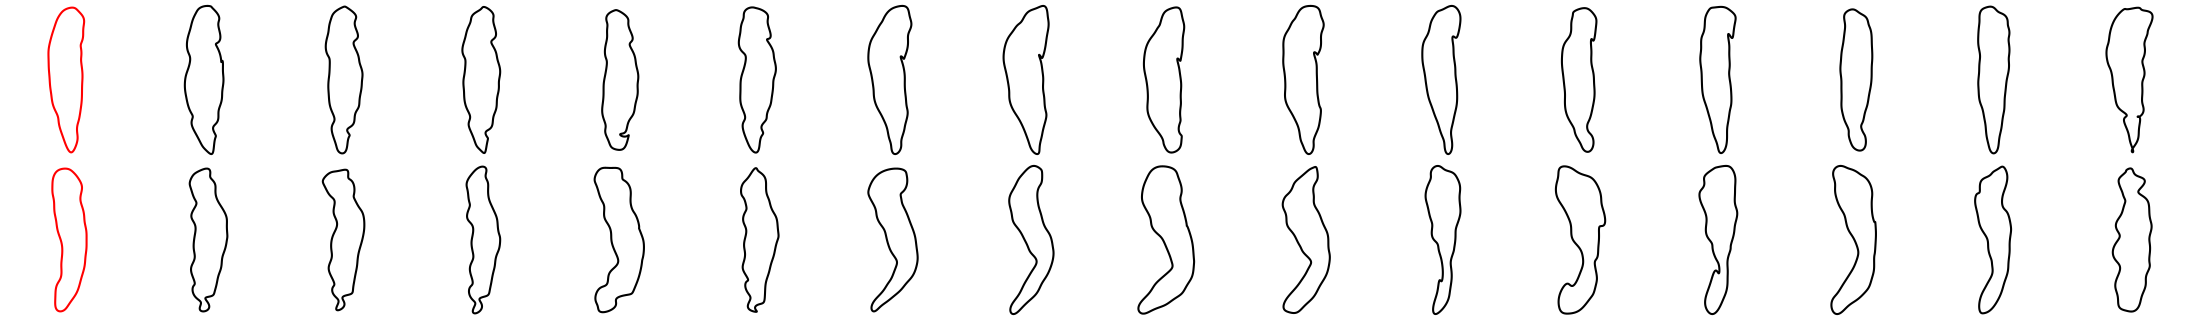

In [ ]:
display(Image(filename="/content/fig2_predicted_F1_contours.png"))

## 7. Predicted F1 EFD table (exportable)

The predicted EFD coefficients written by the glue `write.csv()` line: **30 rows = 15 replicate-pair (`Parent1_Pi_X_Parent2_Pj`, i ≤ j) raw-EFD PPδ predictions per view direction**; the averaged-EFD-based prediction (`Parent1_X_Parent2`) is drawn as the red contour in section 6 but is not part of this CSV (it lives in the script's `Ave_Pre_df`). Below: the table shape and the first few `a`-harmonic columns; the full 82-column table stays at `/content/predicted_F1_EFD.csv` for download from the Colab file browser.

**日本語**: 予測 EFD 係数表(全 82 列)。先頭の数列のみ表示し、完全な表は `/content/predicted_F1_EFD.csv` からダウンロードできます。

In [ ]:
import pandas as pd

pred = pd.read_csv("/content/predicted_F1_EFD.csv")
print("predicted_F1_EFD.csv:", pred.shape[0], "rows x", pred.shape[1], "columns")
pred.iloc[:, :7]  # Direction, Combination, a1..a5

predicted_F1_EFD.csv: 30 rows x 82 columns


,Direction,Combination,a1,a2,a3,a4,a5
0,a,Parent1_P1XParent2_P1,1,0.018650,0.096534,-0.014277,0.023847
1,a,Parent1_P1XParent2_P2,1,-0.019439,0.081711,-0.006525,0.020237
2,a,Parent1_P1XParent2_P3,1,-0.008355,0.082383,-0.006131,0.025609
3,a,Parent1_P1XParent2_P4,1,-0.045651,0.040335,-0.027274,0.011254
4,a,Parent1_P1XParent2_P5,1,-0.000306,0.067464,-0.003256,0.029277
5,a,Parent1_P2XParent2_P2,1,0.038861,0.090659,-0.016632,0.044289
6,a,Parent1_P2XParent2_P3,1,0.049404,0.091331,-0.016238,0.045527
7,a,Parent1_P2XParent2_P4,1,0.012649,0.049283,-0.038425,0.042220
8,a,Parent1_P2XParent2_P5,1,0.057004,0.076412,-0.013362,0.046372
9,a,Parent1_P3XParent2_P3,1,0.086221,0.091500,0.014119,0.044007


## Interpretation, limitations, and validation record

- **What ran**: the authors' own PPδ trial (`TrialScript.R` @ `87d422e2…`) on the authors' own example parents, with byte-verified inputs; contour plots above are this run's actual outputs, not figures copied from the paper.
- **What it does not show**: any accuracy of the published GP[20]/GP[132]/PPmid/PPδ methods — the article full text was not verified, and a single trial cross predicts no validation statistics. The dominance-ratio CSV is the authors' empirical constant from their 156 F1 accessions, used as-is.
- **AI glue** (only deviations from the author script): PNG devices around the two plotting blocks + `write.csv(Pre_df, ...)`; all scientific lines verbatim. Plot pixel sizes are display choices.
- **Runtime used**: recorded in the execution outputs of this notebook (R version printed in the runtime-selection cell). Validated on a fresh Colab **CPU** runtime; no GPU path exists for this method.
- **License note**: the author repository had no LICENSE file at the pinned commit; reuse terms for the code/data were not established and should be confirmed before redistribution.

**日本語**: 本ノートブックは著者の PPδtrial をそのまま実行したものであり、論文の精度評価や全文の検証は含みません。著者リポジトリには LICENSE が無いため、再配布前に利用条件の確認が必要です。

## References

1. Kondo et al., Comput. Electron. Agric. 236 (2025) 110422. https://doi.org/10.1016/j.compag.2025.110422
2. Code & data: https://github.com/kondo238/Chili-Pepper-F1-Fruit-Shape-Prediction (commit `87d422e29d6c3b52cb08e953eb52bc106a748de1`), `Trial_for_F1_fruit_shape_prediction/`.
3. SHAPE program: Iwata H, Ukai Y (2002) SHAPE: a computer program package for quantitative evaluation of biological shapes. J Hered 93:86–87.